In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('dataset.csv')
df.head(2)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uniqueID     53766 non-null  int64
 1   drugName     53766 non-null  str  
 2   condition    53471 non-null  str  
 3   review       53766 non-null  str  
 4   rating       53766 non-null  int64
 5   date         53766 non-null  str  
 6   usefulCount  53766 non-null  int64
dtypes: int64(3), str(4)
memory usage: 28.2 MB


In [6]:
df.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='str')

In [7]:
df.shape

(53766, 7)

In [8]:
df.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [11]:
import html

df['review']=df['review'].apply(html.unescape)
df['rating']=pd.to_numeric(df['rating'],errors='coerce')
df.dropna(subset=['review','rating'],inplace=True)

In [13]:
df['date']=pd.to_datetime(df['date'])
df.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I've tried a few antidepressants over the yea...",10,2012-02-28,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn's disease and has done very ...",8,2009-05-17,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,2017-09-29,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,2017-03-05,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,2015-10-22,4


In [15]:
df['sentiment']=df['rating'].apply(lambda x:'positive' if x>5 else 'negative')


In [16]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment
0,163740,Mirtazapine,Depression,"""I've tried a few antidepressants over the yea...",10,2012-02-28,22,positive
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn's disease and has done very ...",8,2009-05-17,17,positive
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,2017-09-29,3,positive
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,2017-03-05,35,positive
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,2015-10-22,4,positive


In [20]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_review']=df['review'].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\subra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
df.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment,clean_review
0,163740,Mirtazapine,Depression,"""I've tried a few antidepressants over the yea...",10,2012-02-28,22,positive,ive tried antidepressants years citalopram flu...
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn's disease and has done very ...",8,2009-05-17,17,positive,son crohns disease done well asacol complaints...
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,2017-09-29,3,positive,quick reduction symptoms
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,2017-03-05,35,positive,contrave combines drugs used alcohol smoking o...
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,2015-10-22,4,positive,birth control one cycle reading reviews type s...


In [22]:
df[['review','rating','sentiment','clean_review']].head()

,review,rating,sentiment,clean_review
0,"""I've tried a few antidepressants over the yea...",10,positive,ive tried antidepressants years citalopram flu...
1,"""My son has Crohn's disease and has done very ...",8,positive,son crohns disease done well asacol complaints...
2,"""Quick reduction of symptoms""",9,positive,quick reduction symptoms
3,"""Contrave combines drugs that were used for al...",9,positive,contrave combines drugs used alcohol smoking o...
4,"""I have been on this birth control for one cyc...",9,positive,birth control one cycle reading reviews type s...


In [23]:
df=df[['review','rating','sentiment','clean_review']]

In [24]:
df.sample()

,review,rating,sentiment,clean_review
18729,"""This medicine kept the migraine from becoming...",7,positive,medicine kept migraine becoming full blown mad...


In [25]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


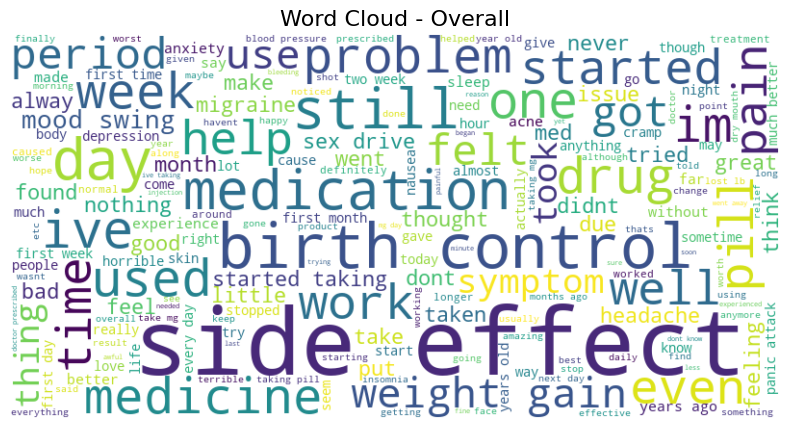

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Overall
plot_wordcloud(' '.join(df['clean_review']), 'Word Cloud - Overall')



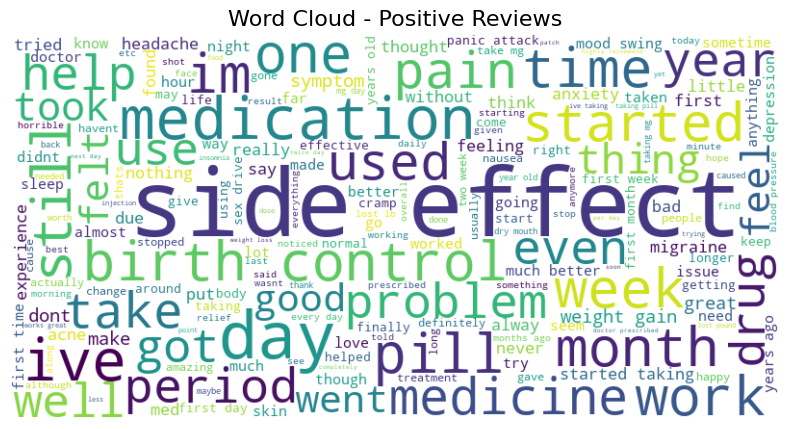

In [30]:
# positive reviews
plot_wordcloud(' '.join(df[df['sentiment'] == 'positive']['clean_review']), 'Word Cloud - Positive Reviews')

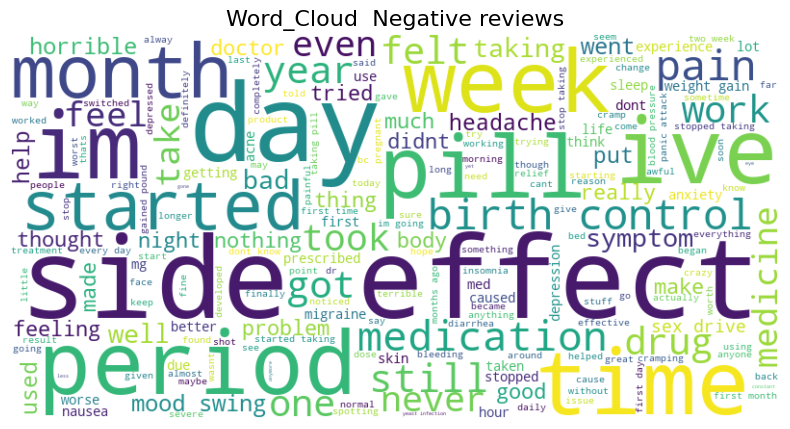

In [31]:
# negative 
plot_wordcloud(' '.join(df[df['sentiment']=='negative']['clean_review']),'Word_Cloud  Negative reviews')

In [32]:
df.sample

<bound method NDFrame.sample of                                                   review  rating sentiment  \
0      "I've tried a few antidepressants over the yea...      10  positive   
1      "My son has Crohn's disease and has done very ...       8  positive   
2                          "Quick reduction of symptoms"       9  positive   
3      "Contrave combines drugs that were used for al...       9  positive   
4      "I have been on this birth control for one cyc...       9  positive   
...                                                  ...     ...       ...   
53761  "I have taken Tamoxifen for 5 years. Side effe...      10  positive   
53762  "I've been taking Lexapro (escitaploprgram) si...       9  positive   
53763  "I'm married, 34 years old and I have no kids....       8  positive   
53764  "I was prescribed Nucynta for severe neck/shou...       1  negative   
53765                                      "It works!!!"       9  positive   

                               

In [33]:
df.shape

(53766, 4)

In [34]:
df.sentiment.value_counts()

sentiment
positive    37559
negative    16207
Name: count, dtype: int64

In [36]:
# Positive and negatuive is not balanced so that we have to do balance for making better model understanding otherwise ML model  will be biased\

# step:-1:- Separate postive and negative sentiments
positive_df=df[df['sentiment']=='positive']
negative_df=df[df['sentiment']=='negative']

# step2:- downgrade  the positve sentiment to as equal as negative sentiment
downgrade_postive = positive_df.sample(n=len(negative_df), random_state=42)

#Step-3:-Concat both downgraded postive and negative df

df_balanced=pd.concat([downgrade_postive,negative_df])

# Shuffle the dataset
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [38]:
df.sentiment.value_counts()

sentiment
positive    16207
negative    16207
Name: count, dtype: int64

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import re

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(df['clean_review']) #converting text to numbers
y=df['sentiment']

In [ ]:
#Train the model
X-train,X-test,y-train,y-test=train_test_split(X,y,test_size=0.2,random_state=43,stratify=y)